# ChurnInsight — Notebook Unificado (EDA + Pipeline + Entrenamiento + Exportación)

Este notebook consolida el flujo completo del MVP:

1. Carga y limpieza del dataset
2. EDA básico (calidad de datos + distribución + desbalance)
3. Definición de features (según contrato v3)
4. Pipeline de preprocesamiento (ColumnTransformer)
5. Entrenamiento y evaluación (Logistic Regression como modelo principal)
6. Exportación del pipeline
7. Prueba de inferencia con un JSON de ejemplo

> Nota: está pensado para ejecutarse en **Google Colab** o local con Python 3.10+.


#  Configuración y reproducibilidad

Para que los resultados sean **reproducibles** al ejecutar el notebook (especialmente en Colab), fijamos una semilla global y `random_state` en los pasos clave.  
> Nota: pequeñas variaciones pueden ocurrir por diferencias de versión o hardware, pero esto reduce al mínimo esas variaciones.


In [1]:
# Reproducibilidad
SEED = 42

import os, random
import numpy as np

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)


##  Cómo ejecutar en Google Colab

1. **Runtime → Run all** (Ejecutar todo).  
2. Si vuelves a correr secciones sueltas, asegúrate de ejecutar primero las celdas de **imports** y **configuración**.  
3. El modelo entrenado queda en `models/` como `.joblib` para integración.


## Guía rápida

Este notebook es el **entregable técnico principal** del equipo de Data Science para el MVP de **ChurnInsight**. Incluye: limpieza, EDA, preprocesamiento, entrenamiento (Regresión Logística), evaluación y validación del contrato.

### Objetivo del modelo
Predecir **churn** (abandono/cancelación) y devolver:
- **forecast**: `"Va a cancelar"` o `"Va a continuar"`
- **probability**: probabilidad (0–1) asociada al churn

> Para el MVP se prioriza **Regresión Logística** por interpretabilidad y estabilidad (más fácil de explicar e integrar que modelos más complejos).

### Cómo ejecutar (Colab / Jupyter)
1. Abrir el notebook en Google Colab.
2. Ejecutar **Runtime → Run all** (o ejecutar celdas en orden).
3. Al final se genera el artefacto del modelo:
   - `models/churn_pipeline_v3_logreg.joblib`

### Dataset
- Fuente: *Bank Customer Churn* (Kaggle) cargado vía `kagglehub` (ver celdas de carga).
- Se eliminan columnas de identificación (ej. `RowNumber`, `CustomerId`, `Surname`) y se conserva el set del **contrato v3**.

### Contrato de integración — v3 (estable)

#### Entrada (JSON, **camelCase** recomendado para backend)
```json
{
  "geography": "Spain",
  "gender": "Male",
  "age": 42,
  "creditScore": 650,
  "balance": 1200.5,
  "estimatedSalary": 45000,
  "tenure": 6,
  "numOfProducts": 2,
  "satisfactionScore": 2,
  "isActiveMember": true,
  "hasCrCard": true,
  "complain": false
}
```

#### Salida (referencia)
```json
{
  "forecast": "Va a cancelar",
  "probability": 0.81
}
```

**Nota de integración:** el microservicio DS puede mapear internamente `camelCase → nombres del dataset/pipeline` para no obligar al backend a enviar PascalCase.

### Variables y preprocesamiento

**Categóricas (One-Hot Encoding)**
- `geography`, `gender`

**Numéricas (Standard Scaling)**
- `age`, `creditScore`, `balance`, `estimatedSalary`, `tenure`, `numOfProducts`, `satisfactionScore`

**Binarias (se usan directo; se convierten a 0/1 si hace falta)**
- `isActiveMember`, `hasCrCard`, `complain`

### Semáforo de importancia (referencia para documentación)
🟢 **Core** (alta señal típica en churn datasets): `age`, `creditScore`, `balance`, `isActiveMember`, `complain`, `numOfProducts`, `satisfactionScore`  
🟡 **Apoyo** (pueden mejorar performance / segmentación): `estimatedSalary`, `tenure`, `gender`, `geography`  
🔴 **No se usan** (IDs / leakage / baja utilidad): `RowNumber`, `CustomerId`, `Surname`

### Validación de dominio (para evitar inputs fuera de distribución)
Dominios esperados por dataset (recomendación para backend + DS):
- `geography`: `"Spain"`, `"France"`, `"Germany"`
- `gender`: `"Male"`, `"Female"`
- `satisfactionScore`: 1–5
- `age`: 18–100 (aprox.)
- `tenure`: 0–10
- `numOfProducts`: 1–4 (si llega un valor fuera, se acepta pero se advierte)

> Estos rangos **no son “reglas universales”**, solo el **dominio observado** en el dataset de entrenamiento del MVP.

### Prueba rápida (si se expone vía API)
```bash
curl -X POST http://localhost:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"geography":"Spain","gender":"Male","age":42,"creditScore":650,"balance":1200.5,"estimatedSalary":45000,"tenure":6,"numOfProducts":2,"satisfactionScore":2,"isActiveMember":true,"hasCrCard":true,"complain":false}'
```


##  Instalación (solo si aplica)

Colab normalmente tiene muchas librerías. Si algo falta:

In [2]:
!pip -q install kagglehub scikit-learn pandas numpy matplotlib joblib

## 1) Carga del dataset

Usamos el dataset de churn bancario (Kaggle) y eliminamos columnas identificadoras (PII).

In [3]:
import os
import numpy as np
import pandas as pd

# Si estás en Colab y vas a usar kagglehub, descomenta:
import kagglehub

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
print('Path:', path)

# Ajusta el nombre si cambia en el futuro
csv_path = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(csv_path)
print('Shape:', df.shape)
df.head()

100%|██████████| 307k/307k [00:00<00:00, 17.3MB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/radheshyamkollipara/bank-customer-churn/versions/1


Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)


In [5]:
import joblib  # para serializar el pipeline

## 2) Limpieza mínima y selección de columnas (contrato v3)

- Target: `Exited`
- Se eliminan: `RowNumber`, `CustomerId`, `Surname`
- Se renombra `Satisfaction Score` → `SatisfactionScore` si aplica


In [6]:
df = df.copy()

# Normalizar nombres
df.columns = [c.strip().replace(' ', '') for c in df.columns]

# Eliminar identificadores
for col in ['RowNumber', 'CustomerId', 'Surname']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Asegurar target
assert 'Exited' in df.columns, f'No se encontró Exited. Columnas: {df.columns.tolist()}'

# Muestra columnas
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 3) EDA básico

Este EDA es intencionalmente conciso: calidad de datos, distribución y desbalance.

Nulos por columna (top):
Series([], dtype: int64)
Distribución target (0=no churn, 1=churn):
Exited
0    7962
1    2038
Name: count, dtype: int64


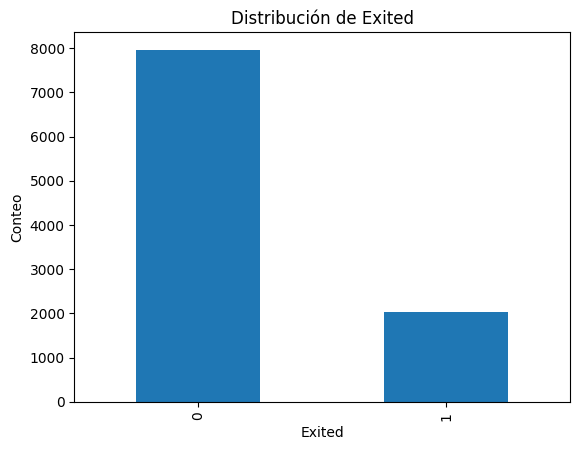

In [7]:
import matplotlib.pyplot as plt

# Nulos
nulls = df.isna().sum().sort_values(ascending=False)
print('Nulos por columna (top):')
print(nulls[nulls>0].head(20))

# Distribución del target
target_counts = df['Exited'].value_counts().sort_index()
print('Distribución target (0=no churn, 1=churn):')
print(target_counts)

plt.figure()
target_counts.plot(kind='bar')
plt.title('Distribución de Exited')
plt.xlabel('Exited')
plt.ylabel('Conteo')
plt.show()

In [8]:
# Resumen estadístico numérico
df.describe(include=[np.number]).T.head(20)

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203800,0.402842,0.00,0.00,0.000,0.0000,1.00
Complain,10000.0,0.204400,0.403283,0.00,0.00,0.000,0.0000,1.00


## 4) Definición de Features (X) y Target (y)

Contrato v3 (raw) esperado por /predict:
- Geography (str)
- Gender (str)
- Age (int)
- CreditScore (int)
- Balance (float)
- EstimatedSalary (float)
- Tenure (int)
- NumOfProducts (int)
- SatisfactionScore (int 1..5)
- IsActiveMember (bool)
- HasCrCard (bool)
- complain (bool)

> En el dataset estas binarias pueden venir como 0/1. En el pipeline las convertimos a 0/1 de forma robusta.

In [9]:
FEATURES = [
    'Geography','Gender','Age','CreditScore','Balance','EstimatedSalary',
    'Tenure','NumOfProducts','SatisfactionScore','IsActiveMember','HasCrCard','Complain'
]

# Algunas versiones usan 'Complain' con C mayúscula. Normalizamos a 'Complain' para el contrato
if 'Complain' in df.columns and 'Complain' not in df.columns:
    df.rename(columns={'Complain':'Complain'}, inplace=True)

# SatisfactionScore ya viene sin espacio por el replace de arriba

# Verifica columnas disponibles
missing = [c for c in FEATURES if c not in df.columns and c!='Complain']
# Ajuste por 'Complain'
if 'Complain' in df.columns:
    if 'Complain' in FEATURES: pass

print('Columnas:', df.columns.tolist())

# Construimos X e y con las columnas del contrato
feature_cols = [
    'Geography','Gender','Age','CreditScore','Balance','EstimatedSalary',
    'Tenure','NumOfProducts','SatisfactionScore','IsActiveMember','HasCrCard','Complain'
]

X = df[feature_cols].copy()
y = df['Exited'].astype(int).copy()
print('X shape:', X.shape, 'y shape:', y.shape)
X.head()

Columnas: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'SatisfactionScore', 'CardType', 'PointEarned']
X shape: (10000, 12) y shape: (10000,)


,Geography,Gender,Age,CreditScore,Balance,EstimatedSalary,Tenure,NumOfProducts,SatisfactionScore,IsActiveMember,HasCrCard,Complain
0,France,Female,42,619,0.00,101348.88,2,1,2,1,1,1
1,Spain,Female,41,608,83807.86,112542.58,1,1,3,1,0,1
2,France,Female,42,502,159660.80,113931.57,8,3,3,0,1,1
3,France,Female,39,699,0.00,93826.63,1,2,5,0,0,0
4,Spain,Female,43,850,125510.82,79084.10,2,1,5,1,1,0


## 5) Pipeline de Preprocesamiento (ColumnTransformer)

- Categóricas: One-Hot
- Numéricas: Imputer + StandardScaler
- Binarias: Cast a int (0/1) + Imputer

Esto asegura que el backend envíe datos crudos y el pipeline haga toda la transformación.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

num_features = ['Age','CreditScore','Balance','EstimatedSalary','Tenure','NumOfProducts','SatisfactionScore']
cat_features = ['Geography','Gender']
bin_features = ['IsActiveMember','HasCrCard','Complain']

# Convertir bool/objetos a 0/1 de forma segura
def to_int01(df_in):
    df_out = df_in.copy()
    for c in df_out.columns:
        df_out[c] = df_out[c].map({True:1, False:0}).fillna(df_out[c])
        df_out[c] = pd.to_numeric(df_out[c], errors='coerce')
    return df_out

bin_pipe = Pipeline(steps=[
    ('to01', FunctionTransformer(to_int01, feature_names_out='one-to-one')),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    ,('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
    ,('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features),
        ('bin', bin_pipe, bin_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (8000, 12) Test: (2000, 12)


In [11]:
assert 'preprocess' in globals(), "No se encontró `preprocess`. Ejecuta la celda de ColumnTransformer antes de entrenar."


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Pipeline completo: preprocess + Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight="balanced", solver='liblinear', random_state=SEED)

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", lr)
])

pipe_lr.fit(X_train, y_train)

# Evaluación básica (priorizando Recall por negocio)
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:, 1]

print("Classification report (LogReg):")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

print("ROC AUC (LogReg):", roc_auc_score(y_test, y_proba))


Classification report (LogReg):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion matrix:
 [[1591    1]
 [   2  406]]
ROC AUC (LogReg): 0.9987806680461129


In [13]:
# Umbral de clasificación (threshold)
# - En este MVP priorizamos Recall (detectar la mayor cantidad posible de churn)
# - Se propuso un umbral bajo (0.22) para capturar más casos de riesgo.
#   Se puede ajustar según el costo de falsos positivos vs falsos negativos.
THRESHOLD = 0.22


##  Ajuste de umbral (opcional)

Por defecto, convertimos probabilidad a clase con umbral **0.5**.  
En churn, muchas veces conviene **bajar el umbral** para aumentar *Recall* (capturar más clientes en riesgo), aceptando algunos falsos positivos.

Esta sección permite evaluar rápidamente distintos umbrales **sin reentrenar**.


In [14]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Requiere y_proba (probabilidades en test) ya calculadas
thresholds = [0.3, 0.4, 0.5, 0.6]
print("Umbral | Precision | Recall | F1")
for t in thresholds:
    y_hat = (y_proba >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_hat, average='binary', zero_division=0)
    print(f"{t:>5}  |  {p:>9.3f} | {r:>6.3f} | {f1:>4.3f}")


Umbral | Precision | Recall | F1
  0.3  |      0.998 |  0.995 | 0.996
  0.4  |      0.998 |  0.995 | 0.996
  0.5  |      0.998 |  0.995 | 0.996
  0.6  |      0.998 |  0.995 | 0.996


### Nota sobre métricas (qué miramos en el MVP)

En churn el costo de *no detectar* a un cliente que sí se va (falso negativo) suele ser alto.
Por eso, para el MVP priorizamos **Recall** de la clase *churn* (Exited=1), aunque esto pueda aumentar algunos falsos positivos.

Si backend/negocio lo solicita, el umbral de decisión puede ajustarse (por ejemplo 0.4/0.6) sin re-entrenar el modelo.


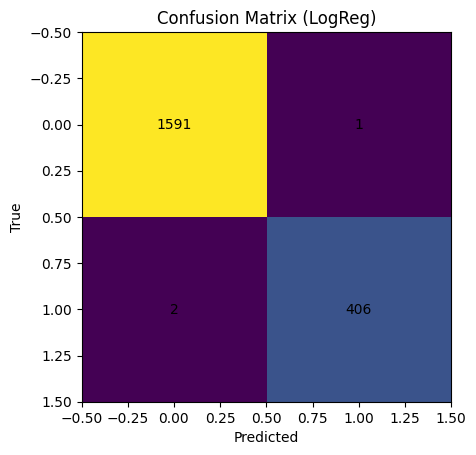

In [15]:
# Matriz de confusión (visualización rápida)
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix (LogReg)")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.show()


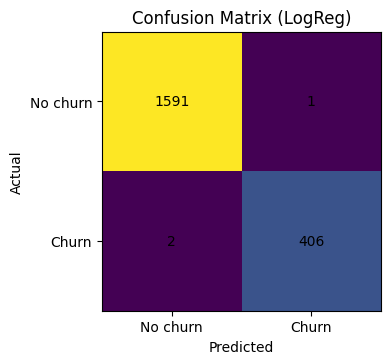

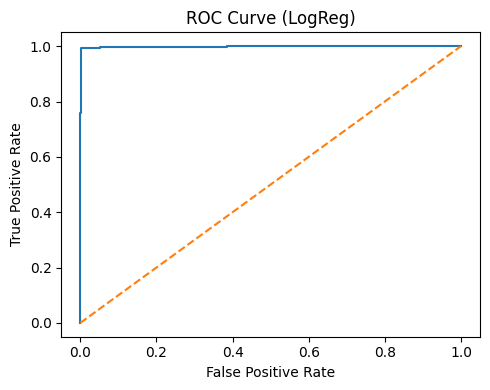

In [16]:
# Visualización rápida (opcional)
import numpy as np
import matplotlib.pyplot as plt

# Matriz de confusión
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (LogReg)')
plt.xticks([0,1], ['No churn','Churn'])
plt.yticks([0,1], ['No churn','Churn'])

for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Curva ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.title('ROC Curve (LogReg)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.tight_layout()
plt.show()


**Reproducibilidad:** se fija `random_state` en los pasos de partición y modelos para que los resultados sean consistentes entre ejecuciones.

In [17]:
def raw_to_matrix(df_raw: pd.DataFrame, fit: bool = False):
    """Recibe datos crudos (DataFrame) con las columnas del contrato v3 y devuelve
    la matriz numérica lista para el modelo (numpy array / sparse matrix).

    - fit=True: ajusta el preprocesador con df_raw y transforma
    - fit=False: solo transforma usando el preprocesador ya ajustado
    """
    X_raw = df_raw.copy()

    # Asegurar columnas esperadas (contrato v3)
    expected = num_features + cat_features + bin_features
    missing = [c for c in expected if c not in X_raw.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    if fit:
        return preprocess.fit_transform(X_raw)
    return preprocess.transform(X_raw)

In [18]:
#  Paso 2 (Entregable): matriz numérica lista para el modelo
# Usamos el preprocesador definido arriba (ColumnTransformer)
# Nota: X_train es el DataFrame crudo (features) antes de cualquier transformación manual.
X_ready = raw_to_matrix(X_train, fit=True)  # ajusta preprocesador con training raw
print("Tipo:", type(X_ready))
print("Shape:", X_ready.shape)

Tipo: <class 'numpy.ndarray'>
Shape: (8000, 15)


##  Contrato v3 (estable)

A continuación se definen funciones para:
- Normalizar el **payload** del contrato v3 (camelCase) a un `DataFrame` con las columnas usadas en entrenamiento.
- Validar rangos/dominios antes de inferir.

> Nota: Esto está pensado para alinear DS y Backend y evitar errores por nombres de columnas.

In [19]:
def validate_domain(df: pd.DataFrame) -> list:
    """Validación suave de dominio/rangos. Devuelve lista de warnings (no detiene ejecución)."""
    warnings = []
    if "Geography" in df.columns:
        allowed_geo = {"Spain", "France", "Germany"}
        bad = set(df["Geography"].dropna().unique()) - allowed_geo
        if bad:
            warnings.append(f"Geography fuera de dominio: {sorted(bad)} (esperado: {sorted(allowed_geo)})")
    if "Age" in df.columns:
        bad = df[(df["Age"] < 18) | (df["Age"] > 95)]["Age"]
        if not bad.empty:
            warnings.append("Age fuera de rango recomendado (18–95).")
    if "Tenure" in df.columns:
        bad = df[(df["Tenure"] < 0) | (df["Tenure"] > 10)]["Tenure"]
        if not bad.empty:
            warnings.append("Tenure fuera de rango recomendado (0–10).")
    if "NumOfProducts" in df.columns:
        bad = df[(df["NumOfProducts"] < 1) | (df["NumOfProducts"] > 4)]["NumOfProducts"]
        if not bad.empty:
            warnings.append("NumOfProducts fuera de rango recomendado (1–4).")
    if "SatisfactionScore" in df.columns:
        bad = df[(df["SatisfactionScore"] < 1) | (df["SatisfactionScore"] > 5)]["SatisfactionScore"]
        if not bad.empty:
            warnings.append("SatisfactionScore fuera de rango recomendado (1–5).")
    for col in ["Balance", "EstimatedSalary"]:
        if col in df.columns:
            bad = df[df[col] < 0][col]
            if not bad.empty:
                warnings.append(f"{col} negativo (esperado >= 0).")
    return warnings

**Tip:** antes de inferir, puedes validar el dominio de datos para evitar inputs fuera de rango.

```python
warnings = validate_domain(df_in)
for w in warnings:
    print('⚠️', w)
```

**Entregable (Paso 2):** `raw_to_matrix(df_raw)` recibe datos crudos (con columnas del contrato v3) y devuelve la **matriz numérica lista** para el modelo.  
Esto asegura que cualquier nuevo input pase por el mismo `ColumnTransformer` usado en entrenamiento.

## 6) Entrenamiento — Logistic Regression (modelo principal)

Se prioriza interpretabilidad y estabilidad. Se usa `class_weight='balanced'` por desbalance de clases.

In [20]:
# Explicabilidad mínima (Logistic Regression): top variables por magnitud del coeficiente
# Nota: en este pipeline el estimador está en el paso 'model'
try:
    feature_names = pipe_lr.named_steps["preprocess"].get_feature_names_out()
    coefs = pipe_lr.named_steps["model"].coef_[0]
    top = (pd.Series(coefs, index=feature_names)
             .sort_values(key=lambda s: s.abs(), ascending=False)
             .head(10))
    display(top)
except Exception as e:
    print("No se pudo extraer importancia por coeficientes:", e)

,0
bin__Complain,10.778159
cat__Gender_Female,-1.351754
cat__Gender_Male,-1.309074
bin__IsActiveMember,-0.990169
cat__Geography_Spain,-0.980796
cat__Geography_France,-0.939360
cat__Geography_Germany,-0.740672
num__Age,0.568559
num__SatisfactionScore,-0.167364
bin__HasCrCard,-0.160827


## 7) (Opcional) Benchmark rápido — Random Forest

Solo como comparación (no necesariamente el modelo elegido para MVP).

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)

pipe_rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', rf)
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]

print('ROC AUC (RF):', roc_auc_score(y_test, y_proba_rf))
print("")

ROC AUC (RF): 0.9989985158636319



## 8) Exportación del Pipeline

Guardamos el pipeline completo (preprocesamiento + modelo) para que el microservicio lo cargue sin pasos extra.

# Reglas de Dominio (Validación) — Backend + DS
# Estas reglas están alineadas con lo acordado en el equipo (contrato v3).
# Objetivo: evitar inferencias fuera del dominio de entrenamiento y entradas inconsistentes.

from typing import List
import pandas as pd

ALLOWED_GEOGRAPHY = {"Spain", "France", "Germany"}
ALLOWED_NUM_PRODUCTS = {1, 2, 3, 4}
ALLOWED_SATISFACTION = {1, 2, 3, 4, 5}

def validate_domain(df_one: pd.DataFrame) -> List[str]:
    warnings = []

    # Se asume df_one ya viene con nombres de entrenamiento:
    # Geography, Gender, Age, CreditScore, Balance, EstimatedSalary, Tenure,
    # NumOfProducts, SatisfactionScore, IsActiveMember, HasCrCard, complain

    # Geography
    if "Geography" in df_one.columns:
        geo = df_one.loc[df_one.index[0], "Geography"]
        if pd.notna(geo) and geo not in ALLOWED_GEOGRAPHY:
            warnings.append(f"Geography fuera de dominio: {geo}. Esperado: {sorted(ALLOWED_GEOGRAPHY)}")

    # Age
    if "Age" in df_one.columns:
        age = df_one.loc[df_one.index[0], "Age"]
        if pd.notna(age) and not (18 <= float(age) <= 100):
            warnings.append(f"Age fuera de rango: {age}. Esperado: 18–100")

    # CreditScore
    if "CreditScore" in df_one.columns:
        cs = df_one.loc[df_one.index[0], "CreditScore"]
        if pd.notna(cs) and not (100 <= float(cs) <= 1000):
            warnings.append(f"CreditScore fuera de rango: {cs}. Esperado: 100–1000")

    # Balance / EstimatedSalary
    for col in ["Balance", "EstimatedSalary"]:
        if col in df_one.columns:
            v = df_one.loc[df_one.index[0], col]
            if pd.notna(v) and float(v) < 0:
                warnings.append(f"{col} fuera de dominio: {v}. Esperado: >= 0")

    # Tenure
    if "Tenure" in df_one.columns:
        t = df_one.loc[df_one.index[0], "Tenure"]
        if pd.notna(t) and not (0 <= float(t) <= 20):
            warnings.append(f"Tenure fuera de rango: {t}. Esperado: 0–20")

    # NumOfProducts
    if "NumOfProducts" in df_one.columns:
        n = df_one.loc[df_one.index[0], "NumOfProducts"]
        if pd.notna(n) and int(n) not in ALLOWED_NUM_PRODUCTS:
            warnings.append(f"NumOfProducts fuera de dominio: {n}. Esperado: {sorted(ALLOWED_NUM_PRODUCTS)}")

    # SatisfactionScore
    if "SatisfactionScore" in df_one.columns:
        s = df_one.loc[df_one.index[0], "SatisfactionScore"]
        if pd.notna(s) and int(s) not in ALLOWED_SATISFACTION:
            warnings.append(f"SatisfactionScore fuera de dominio: {s}. Esperado: {sorted(ALLOWED_SATISFACTION)}")

    # Binarias
    for b in ["IsActiveMember", "HasCrCard", "complain"]:
        if b in df_one.columns:
            v = df_one.loc[df_one.index[0], b]
            if pd.notna(v) and int(v) not in (0, 1):
                warnings.append(f"{b} fuera de dominio: {v}. Esperado: 0/1 (true/false)")

    return warnings


In [22]:
# Helpers: contrato v3 (API) -> DataFrame con columnas EXACTAS de entrenamiento
# Acepta claves en snake_case (API) o PascalCase (algunos ejemplos) y normaliza.
import pandas as pd

CONTRACT_V3_FIELDS = [
    "geography","gender","age","creditScore","balance","estimatedSalary",
    "tenure","numOfProducts","satisfactionScore","isActiveMember","hasCrCard","complain"
]

# Mapeo: contrato(API) -> columnas usadas en entrenamiento (pipeline)
COLUMN_MAP = {
    "geography": "Geography",
    "gender": "Gender",
    "age": "Age",
    "creditScore": "CreditScore",
    "balance": "Balance",
    "estimatedSalary": "EstimatedSalary",
    "tenure": "Tenure",
    "numOfProducts": "NumOfProducts",
    "satisfactionScore": "SatisfactionScore",
    "isActiveMember": "IsActiveMember",
    "hasCrCard": "HasCrCard",
    "complain": "Complain",
}

# Para tolerar inputs con PascalCase
ALT_KEYS = {v: k for k, v in COLUMN_MAP.items()}  # "Geography" -> "geography", etc.

BIN_FIELDS = ["isActiveMember","hasCrCard","complain"]

def _to_bool01(x):
    # Normaliza a 0/1 con tolerancia
    if x is None:
        return None
    if isinstance(x, bool):
        return int(x)
    if isinstance(x, (int, float)):
        return int(x >= 0.5)
    if isinstance(x, str):
        s = x.strip().lower()
        if s in ("true","t","yes","y","1"):
            return 1
        if s in ("false","f","no","n","0"):
            return 0
    return None

def contract_json_to_df(payload: dict) -> pd.DataFrame:
    # 1) normalizar claves: si viene PascalCase, lo pasamos a snake_case
    normalized = {}
    for k, v in payload.items():
        if k in CONTRACT_V3_FIELDS:
            normalized[k] = v
        elif k in ALT_KEYS:
            normalized[ALT_KEYS[k]] = v
        else:
            # ignoramos extras del payload para mantener contrato estricto
            pass

    # 2) completar faltantes con None
    row = {k: normalized.get(k, None) for k in CONTRACT_V3_FIELDS}

    # 3) binarios a 0/1
    for b in BIN_FIELDS:
        row[b] = _to_bool01(row[b])

    # 4) mapear a columnas de entrenamiento
    mapped = {COLUMN_MAP[k]: row.get(k) for k in CONTRACT_V3_FIELDS}
    return pd.DataFrame([mapped])


In [23]:
# =========================
# Guardado de artefactos para integración con Backend
# - churn_model_winner.joblib: pipeline completo (preprocess + modelo)
# - metadata_modelo.json / metadata_modelo.joblib: metadatos (contrato, threshold, versión, etc.)
# =========================
import os, json, joblib
from datetime import datetime

os.makedirs("models", exist_ok=True)

MODEL_FILENAME = "churn_model_winner.joblib"
MODEL_PATH = os.path.join("models", MODEL_FILENAME)

# Guardar pipeline (preprocess + LogisticRegression)
joblib.dump(pipe_lr, MODEL_PATH)
print(" Modelo guardado en:", MODEL_PATH)

# Metadatos útiles para backend / demo
metadata = {
    "model_filename": MODEL_FILENAME,
    "model_type": "LogisticRegression",
    "pipeline": "preprocess + logistic_regression",
    "contract_version": "v3",
    "threshold_forecast_1": THRESHOLD,  # alineado con backend (ej. 0.22)
    "positive_class": "churn (Va a cancelar)",
    "created_at": datetime.utcnow().isoformat() + "Z",
    "features_expected": list(X.columns) if "X" in globals() else None,
}

# Guardar metadatos en JSON (legible)
META_JSON = os.path.join("models", "metadata_modelo.json")
with open(META_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(" Metadata JSON guardada en:", META_JSON)

# Guardar metadatos también en joblib (por si backend lo prefiere)
META_JOBLIB = os.path.join("models", "metadata_modelo.joblib")
joblib.dump(metadata, META_JOBLIB)
print(" Metadata joblib guardada en:", META_JOBLIB)

✅ Modelo guardado en: models/churn_model_winner.joblib
✅ Metadata JSON guardada en: models/metadata_modelo.json
✅ Metadata joblib guardada en: models/metadata_modelo.joblib


/tmp/ipython-input-3377359101.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",


## 9) Prueba de inferencia (simulando request JSON)

Esto replica lo que enviará backend al microservicio de DS.

In [ ]:
# 9) Prueba de inferencia (simulando request JSON)
# Esto replica lo que enviará backend al microservicio de DS.

example_input = {
  "geography": "Spain",
  "gender": "Male",
  "age": 42,
  "creditScore": 650,
  "balance": 1200.5,
  "estimatedSalary": 45000,
  "tenure": 6,
  "numOfProducts": 2,
  "satisfactionScore": 2,
  "isActiveMember": True,
  "hasCrCard": True,
  "complain": False
}

one = contract_json_to_df(example_input)

# (Opcional) validación de dominio: imprime warnings (si aplica)
for w in validate_domain(one):
    print("⚠️", w)

proba = float(pipe_lr.predict_proba(one)[:, 1][0])
forecast = "Va a cancelar" if proba >= THRESHOLD else "Va a continuar"

print({
    "forecast": forecast,
    "probability": round(proba, 4),
    "threshold": THRESHOLD
})


## 10) Prueba “pro” (cargar .joblib y re-predecir)

Esta prueba confirma que el artefacto exportado se puede **cargar desde disco** y producir una predicción, tal como lo hará el Backend/DS microservice.

In [ ]:
# 10) Prueba "pro" (cargar .joblib y re-predecir)
# Confirma que el artefacto exportado se puede cargar desde disco y producir la MISMA predicción.

import joblib

# Asegura que 'one' exista (por si corriste celdas fuera de orden)
try:
    one
except NameError:
    one = contract_json_to_df(example_input)

loaded = joblib.load(MODEL_PATH)

proba_loaded = float(loaded.predict_proba(one)[:, 1][0])
forecast_loaded = "Va a cancelar" if proba_loaded >= THRESHOLD else "Va a continuar"

print({
    "forecast_loaded": forecast_loaded,
    "probability_loaded": round(proba_loaded, 4),
    "threshold": THRESHOLD,
    # tolerancia pequeña por precisión numérica
    "same_as_memory": abs(proba_loaded - proba) < 1e-9
})


---

## Checklist MVP

- [x] Dataset cargado y limpiado
- [x] EDA básico
- [x] Pipeline robusto (ColumnTransformer)
- [x] Modelo interpretable (LogReg)
- [x] Evaluación con métricas
- [x] Exportación de pipeline
- [x] Prueba de inferencia con JSON


##  Exportar un CSV para Power BI

Si  no existe un endpoint `GET` con histórico de predicciones, la forma más simple de mostrar un dashboard es:

1. Generar un **CSV con predicciones** (probability + forecast) a partir de un lote de clientes.
2. Cargar ese CSV en Power BI y construir visualizaciones (tasa de churn, distribución de riesgo, top clientes riesgo, etc.).

> En una evolución “conectada”, Backend podría exponer un endpoint `GET` (por ejemplo `/high-risk` o `/stats`) para que Power BI lo consuma como fuente Web.


In [ ]:
# 📤 Exportar dataset de predicciones para Power BI (CSV)
# Este bloque NO afecta al modelo ni al backend: solo genera un archivo demo para el dashboard.

import os
import numpy as np
import pandas as pd

# 1) Asegurar que existe un pipeline entrenado/cargado
#    - Si ya entrenaste arriba, `pipe_lr` existe.
#    - Si reiniciaste runtime, intenta cargarlo desde models/.
try:
    pipe_lr
except NameError:
    import joblib
    # Ajusta si tu backend usa otro nombre
    CANDIDATES = [
        "models/churn_model_winner.joblib",
        "models/churn_pipeline_v3_logreg.joblib",
        "models/churn_pipeline.joblib",
    ]
    found = None
    for p in CANDIDATES:
        if os.path.exists(p):
            found = p
            break
    if found is None:
        raise FileNotFoundError(
            "No se encontró un .joblib en /models. Entrena el modelo arriba o coloca el archivo en models/."
        )
    pipe_lr = joblib.load(found)
    print(f"✅ Pipeline cargado desde: {found}")

# 2) Tomar una muestra del dataframe ya limpio (df)
if "df" not in globals():
    raise NameError("No existe `df` en el notebook. Revisa la celda de carga/limpieza del dataset.")

sample_n = min(1000, len(df))
df_sample = df.sample(sample_n, random_state=42).copy()

# 3) Preparar features (X) y predecir
#    Si tu df tiene la etiqueta (Exited), la quitamos para predecir.
target_candidates = [c for c in ["Exited", "exited", "target", "Churn"] if c in df_sample.columns]
if len(target_candidates) > 0:
    y_col = target_candidates[0]
    X = df_sample.drop(columns=[y_col])
else:
    X = df_sample

# Probabilidad de churn (clase 1)
proba = pipe_lr.predict_proba(X)[:, 1]

# Umbral alineado con backend/DS (ajústalo si el equipo lo cambió)
THRESHOLD = 0.22
forecast_int = (proba >= THRESHOLD).astype(int)

# 4) Crear columnas de soporte para Power BI
#    - timestamp simula varios días para que "Risk Trend Over Time" tenga variación temporal.
start_date = pd.Timestamp.today().normalize() - pd.Timedelta(days=29)
timestamps = start_date + pd.to_timedelta(
    np.random.randint(0, 30, size=sample_n), unit="D"
)
# opcional: horas aleatorias
timestamps = timestamps + pd.to_timedelta(np.random.randint(0, 24, size=sample_n), unit="h")

out = pd.DataFrame({
    "customerId": [f"CUST-{i:05d}" for i in range(1, sample_n + 1)],
    "probability": np.round(proba, 6),
    "forecast": forecast_int,
    "timestamp": timestamps,
})

# 5) Agregar algunas columnas del contrato si están presentes (para filtros en el dashboard)
keep_cols = [
    "Geography", "Gender", "Age", "CreditScore", "Balance", "EstimatedSalary",
    "Tenure", "NumOfProducts", "SatisfactionScore", "IsActiveMember", "HasCrCard", "complain"
]
present = [c for c in keep_cols if c in df_sample.columns]
if present:
    out = pd.concat([out, df_sample[present].reset_index(drop=True)], axis=1)

# 6) Guardar archivo
os.makedirs("exports", exist_ok=True)
CSV_PATH = "exports/predictions_powerbi_demo.csv"
out.to_csv(CSV_PATH, index=False)

print(f"✅ CSV listo para Power BI: {CSV_PATH}")
print(out.head(3))
